In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

False

In [3]:
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

In [4]:
!pip install langchain langchain-openai langchain-community langgraph python-dotenv langchain-mcp-adapters langchain-chroma chromadb pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.

In [5]:
!pip install -U "langchain>=1.3.14"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.4 MB/s eta 0:00:00
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.15
    Uninstalling langchain-1.3.15:
      Successfully uninstalled langchain-1.3.15


In [6]:
from langchain.chat_models import init_chat_model

model = init_chat_model('openai:gpt-5-mini')
model.invoke('Hi')
print("Cinebot's Brain is connected")

Cinebot's Brain is connected


In [7]:
from langchain_core.tools import tool
import sqlite3


In [8]:
@tool
def save_trip_demo(user_id: str, destination: str) -> str:
    """Save a trip to the database. Irreversible without manual cleanup."""
    return f"Trip to {destination} saved for {user_id}."  # standing in for a real DB write

In [9]:
from langchain.agents import create_agent

from langchain.agents.middleware import SummarizationMiddleware


agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[save_trip_demo],
    middleware=[
        SummarizationMiddleware(
            model = 'gpt-5.4-mini',
            trigger = ('tokens',4000),
            keep =('messages',10),
        )
    ])

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def your_read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def your_send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-5.5",
    tools=[your_read_email_tool, your_send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "your_send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "your_read_email_tool": False,
            }
        ),
    ],
)

In [11]:
config = {'configurable':{"thread_id":"hitl"}}

result = agent.invoke({"messages": [("user", "Send an email to my manager on sandeepmgr@gmail.com, asking for a leave")]}, config=config)

```
User
  │
  │ "Send an email asking for leave"
  ▼
LLM
  │
  │ decides to call
  ▼
your_send_email_tool
  │
  │ requires approval
  ▼
INTERRUPT
  │
  ├── approve → send email
  ├── edit    → modify tool arguments
  └── reject  → don't send
```

In [12]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime

In [13]:
# --- LangGraph (checkpointing, resuming) ---
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

In [14]:
from langchain.agents.middleware import (
    SummarizationMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    TodoListMiddleware,
    LLMToolSelectorMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    LLMToolEmulator,
    ContextEditingMiddleware,
    ClearToolUsesEdit,
)

In [15]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")



In [16]:

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."


In [21]:
@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."


In [17]:
@tool
def check_order_status(booking_id: str) -> str:
    """Check the status of an existing booking."""
    return f"Booking {booking_id}: confirmed, 2 seats, Interstellar, 7:00 PM."


In [18]:
@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

In [19]:

@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."


In [22]:
cinebot_tools = [check_showtimes, book_seats, cancel_booking, check_order_status, get_refund_policy, lookup_seat_map]

In [ ]:
def pretty_print_messages(result):
    for i, message in enumerate(result.get("messages", []), 1):
        print(f"\n{'=' * 80}")
        print(f"Message {i}: {message.__class__.__name__}")
        print("=" * 80)

        # Basic message information
        print(f"ID: {getattr(message, 'id', None)}")

        # Message content
        content = getattr(message, "content", "")
        if content:
            print("\nContent:")
            print(content)

        # Tool calls
        tool_calls = getattr(message, "tool_calls", None)
        if tool_calls:
            print("\nTool Calls:")
            for tool in tool_calls:
                print(f"  • {tool['name']}")
                print(f"    Args: {tool['args']}")
                print(f"    ID:   {tool['id']}")

        # Tool message information
        tool_call_id = getattr(message, "tool_call_id", None)
        if tool_call_id:
            print(f"\nTool Call ID: {tool_call_id}")

        # Summarization information
        additional_kwargs = getattr(message, "additional_kwargs", {})
        if additional_kwargs.get("lc_source"):
            print(f"\nSource: {additional_kwargs['lc_source']}")

    print(f"\n{'=' * 80}")
    print("END OF MESSAGE HISTORY")
    print("=" * 80)

In [ ]:
summarizing_agent = create_agent(
    model="gpt-5.4-mini",
    tools=cinebot_tools,
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=("tokens", 300),
            keep=("messages", 1),
        )
    ],
)

In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Hi I am Sandeep")]}))

{'messages': [HumanMessage(content='Hi I am Sandeep', additional_kwargs={}, response_metadata={}, id='606a4725-84a3-428d-a596-e9f506cdfdc4'), AIMessage(content='Hi Sandeep! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 282, 'total_tokens': 297, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-ED4JcKfbWliUtJyDqIDNbNFWmIWOR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a00499-6cec-7143-9336-00be65a93962-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 282, 'output_tokens': 15, 'total_tokens': 297, 'input_token_details': {'audio': 0, 'ca

In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

{'messages': [HumanMessage(content='Who am I ? ', additional_kwargs={}, response_metadata={}, id='9c3e9a78-6a60-4e86-832e-cf4444670817'), AIMessage(content='I don’t know who you are unless you tell me.\n\nIf you mean:\n- **your identity in this chat**: I only know what you type here.\n- **your account/persona**: I don’t have access to that.\n- **a philosophical question**: then you’re the person asking, with your own history, choices, and perspective.\n\nIf you want, I can help you figure it out in a more reflective way.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 281, 'total_tokens': 374, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 

In [ ]:
result = summarizing_agent.invoke({"messages": [("user", "Is Interstellar showing tonight? also please make sure that you book me a ticket, refund me if it is not available,also share the refund policy for me to go through, also check my order status for book_1234")]})

In [ ]:
pretty_print_messages(result)


Message 1: HumanMessage
ID: 937025ca-2ef4-4976-93a7-cd379fb0936a

Content:
Here is a summary of the conversation to date:

## SESSION INTENT

The user wants to know whether *Interstellar* is showing tonight, book a ticket if available, refund them if it is not available, share the refund policy, and check the order status for `book_1234`.

## SUMMARY

The only user request in the conversation is a combined movie-ticket workflow:
- Check whether *Interstellar* is playing tonight.
- If available, book a ticket.
- If not available, issue a refund.
- Provide the refund policy for review.
- Check the status of order `book_1234`.

No actions have been completed yet, and no decisions have been made.

## ARTIFACTS

None

## NEXT STEPS

- Check tonight’s show availability for *Interstellar*.
- If available, proceed with booking a ticket.
- If unavailable, process a refund.
- Retrieve and share the refund policy.
- Check order status for `book_1234`.

Source: summarization

Message 2: AIMessage

# HITL (Human in the Loop)

In [ ]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)

config = {'configurable':{'thread_id':'hitl-demo-live'}}

In [ ]:
print(guarded_agent.invoke({"messages": [("user", "I am Sandeep. ")]}),config=config)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
print(summarizing_agent.invoke({"messages": [("user", "Who am I ? ")]}))

{'messages': [HumanMessage(content='Who am I ? ', additional_kwargs={}, response_metadata={}, id='adf39f30-8078-4acd-9e98-afb9a37d5abc'), AIMessage(content='I don’t know who you are from this conversation alone.\n\nIf you want, I can help you figure it out by asking a few questions, or you can tell me a bit about yourself and I’ll respond accordingly.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 281, 'total_tokens': 328, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-ED4cB34K49TiKI0CkpPm3dzlYg5fr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a004ab-0195-7022-a922-51003c332330-0', t

In [ ]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [ ]:
from rich import print

In [ ]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='6861f83b-ed6f-41d3-9ce2-be46fd6b6189'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 282,
                    'total_tokens': 372,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-ED4dXAnKrOnlNwbUqOv8HqMJrPlT0',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a004ac-4ace-7b20-9017-4a855968e86a-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_3wiMzvCmibXE4Wvf1msYoMZ0',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 90,
                'total_tokens': 372,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='caf99f84a301da1af41ced07a972a383'
        )
    ]
}

In [ ]:
state = guarded_agent.get_state(config)

In [ ]:
state # Please paste it into Chat GPT and ask it to explain the same or Mayank GPT

StateSnapshot(values={'messages': [HumanMessage(content='Please cancel booking BK1042', additional_kwargs={}, response_metadata={}, id='6861f83b-ed6f-41d3-9ce2-be46fd6b6189'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 282, 'total_tokens': 372, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-ED4dXAnKrOnlNwbUqOv8HqMJrPlT0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a004ac-4ace-7b20-9017-4a855968e86a-0', tool_calls=[{'name': 'cancel_booking', 'args': {'booking_id': 'BK1042'}, 'id': 'call_3wiMzvCmibXE4Wvf1msYoMZ0', 'type': 'tool_call'}], invalid_tool_calls=

In [ ]:
print(state.tasks[0])

PregelTask(
    id='41fece28-728c-2b6a-6d25-848e7938eef3',
    name='HumanInTheLoopMiddleware.after_model',
    path=('__pregel_pull', 'HumanInTheLoopMiddleware.after_model'),
    error=None,
    interrupts=(
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='caf99f84a301da1af41ced07a972a383'
        ),
    ),
    state=None,
    result=None
)

In [ ]:
resumed_result = guarded_agent.invoke(Command(resume={"decisions":[{"type":"approve"}]}),config=config)

In [ ]:
print(resumed_result)

{
    'messages': [
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='6861f83b-ed6f-41d3-9ce2-be46fd6b6189'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 90,
                    'prompt_tokens': 282,
                    'total_tokens': 372,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-ED4dXAnKrOnlNwbUqOv8HqMJrPlT0',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a004ac-4ace-7b20-9017-4a855968e86a-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_3wiMzvCmibXE4Wvf1msYoMZ0',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 90,
                'total_tokens': 372,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Booking BK1042 cancelled.',
            name='cancel_booking',
            id='4bf86993-1280-479c-9a6a-c4e781cd0da9',
            tool_call_id='call_3wiMzvCmibXE4Wvf1msYoMZ0'
        ),
        AIMessage(
            content='Done — booking BK1042 has been cancelled.',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 319,
                    'total_tokens': 332,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-ED4fZ14QOTBtoFSsUsmtcFwU3JZyz',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a004ae-3667-7470-b6ca-4850b26cae02-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 319,
                'output_tokens': 13,
                'total_tokens': 332,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [ ]:
state.next

('HumanInTheLoopMiddleware.after_model',)

In [ ]:
def run_interactive_hitl_demo(agent, config):
    """A genuinely interactive HITL loop -- ask out loud, type the answer, watch it apply live."""
    state = agent.get_state(config)
    if not state.next:
        print("Nothing is currently paused for approval.")
        return

    print("The agent wants to call a guarded tool. Choose a decision:")
    print("  1) approve  -- run it exactly as proposed")
    print("  2) edit     -- run it, but change the booking_id first")
    print("  3) reject   -- block it, with a reason sent back to the agent")
    print("  4) respond  -- answer a question instead of deciding on the action")

    choice = input("Type 1, 2, 3, or 4: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("New booking_id to use instead: ").strip()
        decision = {"type": "edit", "args": {"booking_id": new_id}}
    elif choice == "3":
        reason = input("Reason for rejecting: ").strip()
        decision = {"type": "reject", "message": reason}
    elif choice == "4":
        answer = input("Your response to the agent: ").strip()
        decision = {"type": "respond", "message": answer}
    else:
        print("Not a valid choice -- try again.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config)
    print()
    print("Agent's final response:", resumed["messages"][-1].content)


In [ ]:
config = {'configurable':{'thread_id':'hitl-demo-live-2'}}

In [ ]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)


In [ ]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)

In [ ]:
run_interactive_hitl_demo(guarded_agent, config)

The agent wants to call a guarded tool. Choose a decision:

1) approve  -- run it exactly as proposed

2) edit     -- run it, but change the booking_id first

3) reject   -- block it, with a reason sent back to the agent

4) respond  -- answer a question instead of deciding on the action

Type 1, 2, 3, or 4: 1


Agent's final response: Done — booking BK1042 has been cancelled. Would you like me to help with anything else 
(book another ticket, check refunds, view showtimes)?

> ⚙️ **Code Walkthrough:** `Command(resume={"decisions": [...]})` is how you hand a decision
> back to an agent that's paused mid-run. The `decisions` list has one entry per interrupted
> tool call (usually just one). Each decision is a dict with a `"type"` key matching one of the
> four options, plus whatever extra data that type needs — `edit` needs new `args`, `reject` and
> `respond` need a `message`, `approve` needs nothing else.

# Model Call Limit

In [ ]:
call_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),  # required for thread_limit to persist across calls
    middleware=[
        ModelCallLimitMiddleware( # low values taken just for example
            thread_limit=5,   # across the WHOLE conversation
            run_limit=2,       # per single .invoke() call
            exit_behavior="end",  # graceful stop, not an exception
        ),
    ],
)

In [ ]:
result = call_limited_agent.invoke(
    {"messages": [("user", "Can you tell me cinema's refund policy? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result)

{'messages': [HumanMessage(content="Can you tell me cinema's refund policy? ", additional_kwargs={}, response_metadata={}, id='658e542c-5f38-4384-b0f1-2ada6bff1642'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 286, 'total_tokens': 371, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEB1zdLG3WCbzHRjkaDCijImBfXwt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01457-edc8-70b2-b814-9cb3949c075d-0', tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'call_d9zikR2sxtkLi57mjZQQCkWm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

In [ ]:
result_invoke_2= call_limited_agent.invoke(
    {"messages": [("user", "cancel my booking B123? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
result_invoke3 = call_limited_agent.invoke(
    {"messages": [("user", "What all movies are being shown? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result_invoke3)

{'messages': [HumanMessage(content="Can you tell me cinema's refund policy? ", additional_kwargs={}, response_metadata={}, id='658e542c-5f38-4384-b0f1-2ada6bff1642'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 286, 'total_tokens': 371, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEB1zdLG3WCbzHRjkaDCijImBfXwt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01457-edc8-70b2-b814-9cb3949c075d-0', tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'call_d9zikR2sxtkLi57mjZQQCkWm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

In [ ]:
result_invoke4 = call_limited_agent.invoke(
    {"messages": [("user", "Summarize my chat? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

In [ ]:
print(result_invoke4)

{'messages': [HumanMessage(content="Can you tell me cinema's refund policy? ", additional_kwargs={}, response_metadata={}, id='658e542c-5f38-4384-b0f1-2ada6bff1642'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 85, 'prompt_tokens': 286, 'total_tokens': 371, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEB1zdLG3WCbzHRjkaDCijImBfXwt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01457-edc8-70b2-b814-9cb3949c075d-0', tool_calls=[{'name': 'get_refund_policy', 'args': {}, 'id': 'call_d9zikR2sxtkLi57mjZQQCkWm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

# Model Fallback

In [ ]:
resilient_agent = create_agent(
    model="openai:gpt-5.5-haiku",     # primary, most capable
    tools=cinebot_tools,
)

In [ ]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

NotFoundError: Error code: 404 - {'error': {'message': 'The model `gpt-5.5-haiku` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'param': None, 'code': 'model_not_found'}}

In [ ]:
resilient_agent = create_agent(
    model="openai:gpt-5.5-haiku",     # primary, most capable
    tools=cinebot_tools,
    middleware=[
        ModelFallbackMiddleware(
            "openai:gpt-5-mini",   # fallback -- cheaper, still OpenAI, needs no extra setup
            # "ollama:llama3.2",   # a further, fully-local last resort -- uncomment if you have
                                    # `pip install langchain-ollama` AND a local Ollama server running.
                                    # Left commented here so this cell runs with nothing beyond
                                    # what Setup already installed.
        ),
    ],
)
print("Fallback chain: gpt-5.5 -> gpt-5-mini.")
print("If the primary model call fails for any reason, this silently tries the next one.")

Fallback chain: gpt-5.5 -> gpt-5-mini.
If the primary model call fails for any reason, this silently tries the next one.


In [ ]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)

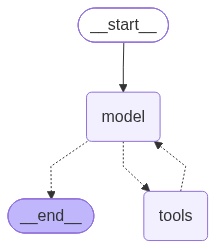

In [ ]:
from IPython.display import Image, display

graph = resilient_agent.get_graph()

display(Image(graph.draw_mermaid_png()))

In [ ]:
print(result)

{'messages': [HumanMessage(content='Summarize my chat? ', additional_kwargs={}, response_metadata={}, id='7cf97414-6f8a-4afb-bcf7-f761d9c17c2e'), AIMessage(content='Do you mean this current conversation or a different chat (e.g., a chat log from another app)? I can summarize either, but I need one thing from you:\n\n- If it’s a different chat: paste the chat text here or upload the file / give the content you want summarized.\n- If it’s this conversation: do you want a very short summary or a more detailed one?\n\nAlso tell me which summary style you prefer (pick one):\n- Short (1–2 lines)\n- Bulleted highlights\n- Timeline / step-by-step\n- Action items and next steps\n- Detailed with quotes and sentiment\n\nOptional preferences: redact personal data? include timestamps? maximum length?\n\nTell me which chat and which style, or paste the text, and I’ll summarize.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 421, 'prompt_tokens': 283, '

# Tool Call Limit

In [ ]:
tool_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2),  # tighter, one tool, whole conversation
    ],
)

# 9th August

**Fraud detection in fintech:** a `wrap_tool_call`-style hook around every transaction-executing
tool, flagging or blocking based on velocity, amount, or pattern — exactly `CineBotComplianceMiddleware`'s
rate-limiting logic, aimed at fraud instead of booking abuse.

**Healthcare AI assistants:** `PIIMiddleware`-style redaction is often a genuine *legal*
requirement (HIPAA in the US) — the pattern from Part 2's PII sections isn't optional polish in
that industry, it's the difference between compliant and non-compliant software.

**Customer support platforms:** `HumanInTheLoopMiddleware`-style approval gates before any action
with real financial consequence (refunds, account changes) — the exact shape used to guard
`cancel_booking` here, used to guard a real refund tool there.

**Internal developer tools:** audit logging via `wrap_tool_call`, like Part 3's
`BookingAuditMiddleware`, is close to universal in any system where "who did what, when" needs a
real answer — compliance, debugging, or just accountability.

In [ ]:
tool_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2, run_limit=1),  # tighter, one tool, whole conversation
    ],
)

In [ ]:
config = {"configurable": {"thread_id": "tool-limit-demo"}}


In [ ]:
for i in range(3):
  result = tool_limited_agent.invoke({"messages": [("user", f"Please cancel my Booking with ID B{100+i} ? ")]}, config=config)
  print(result)

{'messages': [HumanMessage(content='Please cancel my Booking with ID B100 ? ', additional_kwargs={}, response_metadata={}, id='8d576485-5ff5-4562-814b-5e01589d3e41'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 286, 'total_tokens': 311, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EECdLVegTv8WDwiPMABEt5LAycMJo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a014b5-ec52-7e72-9194-23c5888a7c9b-0', tool_calls=[{'name': 'cancel_booking', 'args': {'booking_id': 'B100'}, 'id': 'call_dnWmT4UZrPzzPa0YvPHcxEhZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_me

# PII Detection

In [ ]:
pii_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [ ]:
result = pii_agent.invoke({
    "messages": [("user", "My email is priya@example.com and my credit card is 4111-1111-1111-1234, can you check showtimes for Dune?")]
})

In [ ]:
print(result['messages'][-1].content)

I couldn’t find any showtimes for "Dune" with the information provided.

I also noticed you pasted an email address and a credit card number. For your safety, please do not share payment details or other sensitive personal data here — I can’t process payments and it’s unsafe to post card numbers in chat. I won’t use or store those details; please delete them from this conversation if you can.

If you’d like me to try again, tell me:
- Which "Dune" (e.g., Dune (2021), Dune: Part Two (2024), Dune (1984))?
- City or ZIP code (or specific cinema name)
- Date (or date range) and preferred time (morning/afternoon/evening)

Alternatively I can search nearby cinemas for any Dune showings if you allow location or give a ZIP code. Which would you prefer?


In [ ]:
print(result)

{'messages': [HumanMessage(content='My email is [REDACTED_EMAIL] and my credit card is 4111-1111-1111-1234, can you check showtimes for Dune?', additional_kwargs={}, response_metadata={}, id='ee558293-5e9f-423e-b3b5-2f6e8b3e1029'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 313, 'total_tokens': 403, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEEC4Dr9BJLs9isDbClE1aUAMhsvR', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01511-710d-7142-a142-8a746cdaa541-0', tool_calls=[{'name': 'check_showtimes', 'args': {'movie_title': 'Dune'}, 'id': 'call_PnSekTF0Hicxr

In [ ]:
# BK1101

In [ ]:
import re

In [ ]:
#https://reference.langchain.com/python/langchain/agents/middleware/pii/PIIMiddleware

In [ ]:
def detect_booking_code(content: str) -> list[dict]:
    """Detect CineBot's own booking code format: BK followed by 4 digits."""
    matches = []
    for match in re.finditer(r"BK\d{4}", content):
        matches.append({"text": match.group(0), "start": match.start(), "end": match.end()})
    return matches


In [ ]:
custom_pii_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[PIIMiddleware("booking_code", detector=detect_booking_code, strategy="mask")],
)

In [ ]:
result = custom_pii_agent.invoke({
    "messages": [("user", "Can you check the status of my booking BK1044 for me?")]
})

In [ ]:
print(result)

{'messages': [HumanMessage(content='Can you check the status of my booking ****1044 for me?', additional_kwargs={}, response_metadata={}, id='feb38b61-a3ae-448c-afae-f29722d07a64'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 290, 'total_tokens': 381, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEEZlajVRRcyTzaPLfkAOOrCPIfS9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01527-d943-7e30-9769-fce6450615ca-0', tool_calls=[{'name': 'check_order_status', 'args': {'booking_id': '****1044'}, 'id': 'call_0QhWImh3v6C6E8IAs6zKq6gq', 'type': 'tool_call'}], invalid

# TO Do List

In [ ]:
todo_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[TodoListMiddleware()],
)

In [ ]:
result = todo_agent.invoke({
    "messages": [("user", "I want to plan a movie night: check what's showing, pick something good, and book 2 seats.")]
})

In [ ]:
print(result)

{'messages': [HumanMessage(content="I want to plan a movie night: check what's showing, pick something good, and book 2 seats.", additional_kwargs={}, response_metadata={}, id='f05b0f97-b694-4cc4-be56-043fdafec983'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 606, 'prompt_tokens': 1484, 'total_tokens': 2090, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 512, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EEEvvgMri0v4Tenul4vB7fmqpY28x', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0153c-d1d6-70f1-87a0-ee0b4c36d43a-0', tool_calls=[{'name': 'write_todos', 'args': {'todos': [{'content': 'Ask user for cinema/location and preferre

# LLM Tool Selector

In [ ]:
for tool in cinebot_tools:
  print (tool.name)

check_showtimes
book_seats
cancel_booking
check_order_status
get_refund_policy
lookup_seat_map


In [ ]:
from langchain.agents.middleware import wrap_model_call

@wrap_model_call
def show_tools(request, handler):
    print("\nTOOLS SENT TO MODEL:")
    print([tool.name for tool in request.tools])

    return handler(request)

In [ ]:
selector_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        LLMToolSelectorMiddleware(
            model="openai:gpt-5-mini",     # can be a CHEAPER model than the main agent
            max_tools=2,
            always_include=["check_showtimes"],  # always kept, doesn't count against max_tools
        ),
        show_tools
    ],
)

In [ ]:
result = selector_agent.invoke({"messages": [("user", "Can you cancel my booking with ID B1234?")]})


TOOLS SENT TO MODEL:
['cancel_booking', 'check_order_status', 'check_showtimes']

TOOLS SENT TO MODEL:
['cancel_booking', 'check_order_status', 'check_showtimes']


In [ ]:
print(result)

{'messages': [HumanMessage(content='Can you cancel my booking with ID B1234?', additional_kwargs={}, response_metadata={}, id='3e53fc1e-760e-41d3-99da-f955efcde48e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 190, 'total_tokens': 280, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EExn5tJTv9moJZy2VHOGERlRrVr5O', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a01f83-ee2d-7532-866b-9858dee7c8c8-0', tool_calls=[{'name': 'cancel_booking', 'args': {'booking_id': 'B1234'}, 'id': 'call_GLdyIJFHEhc4nafXPQNllZ3R', 'type': 'tool_call'}], invalid_tool_calls=[], usage_

# Tool Error

In [23]:
from rich import print

In [24]:
import langchain

print(langchain.__version__)

1.3.16

In [25]:
!pip install -U "langchain>=1.3.14"

In [26]:
from langchain.agents.middleware import ToolErrorMiddleware


In [27]:
def on_seat_error(exc: Exception, request) -> str | None:
    if isinstance(exc, ValueError):
        # Return the EXCEPTION TYPE, not str(exc) -- internal detail never reaches the model
        return f"`{request.tool_call['name']}` failed with {type(exc).__name__}. Please provide a valid seat number like 'A12'."
    return None  # anything else propagates and halts the run


In [28]:
error_handled_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[ToolErrorMiddleware(on_error=on_seat_error)],
)

In [29]:
result = error_handled_agent.invoke({"messages": [("user", "Look up seat 12 for Dune Part Two")]})

In [30]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Look up seat 12 for Dune Part Two',
            additional_kwargs={},
            response_metadata={},
            id='2c8ea410-0c1c-4890-a482-2c37012d751f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 34,
                    'prompt_tokens': 286,
                    'total_tokens': 320,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFGvz9caeKSuGnXpgDLZR9XgVEBhv',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a023e6-c7a9-7271-ac83-2ab8c3e0f1c0-0',
            tool_calls=[
                {
                    'name': 'lookup_seat_map',
                    'args': {'movie_title': 'Dune Part Two', 'seat_number': '12'},
                    'id': 'call_vi7pElWJBii6oRrW949VuCQi',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 34,
                'total_tokens': 320,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content="`lookup_seat_map` failed with ValueError. Please provide a valid seat number like 'A12'.",
            name='lookup_seat_map',
            id='720a0257-589b-4148-b57e-cb8c10e19b75',
            tool_call_id='call_vi7pElWJBii6oRrW949VuCQi',
            status='error'
        ),
        AIMessage(
            content='I need the full seat identifier including the row letter (format like "A12"). You gave only 
"12", which caused an error.\n\nWhich row should I use for seat 12 (for example A12, B12, C12)? If you don’t know 
the row, I can instead:\n- show the available rows and seats for Dune Part Two, or\n- search for any available "12"
seats across rows and return the matches.\n\nWhich would you like?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 298,
                    'prompt_tokens': 349,
                    'total_tokens': 647,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 192,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFGw0xnBLvECtAUXUugFnP6xCBDUX',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a023e6-d0d7-7f40-a395-cec48e6b4063-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 349,
                'output_tokens': 298,
                'total_tokens': 647,
      

# Tool Rety

In [31]:
from langchain.agents.middleware import ToolRetryMiddleware

import random
random.random()

0.12099666332724912

In [33]:
import random
@tool
def flaky_showtime_check(movie_title: str) -> str:
    """Check showtimes via an external service that can transiently fail."""
    if not random.random() > 1:
        print("Facing Connection Error")
        raise ConnectionError("Simulated network failure -- exactly what a real external call risks.")
    return f"{movie_title}: showing at 8:00 PM."


In [34]:

resilient_tool_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[flaky_showtime_check],
    middleware=[
        ToolRetryMiddleware(
            max_retries=3, # retries is 3, total it will run for 4 times
            backoff_factor=2.0,
            initial_delay=1.0,
            on_failure="continue"
            ),
    ],

)

In [35]:
result = resilient_tool_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})


Facing Connection Error

Facing Connection Error

Facing Connection Error

Facing Connection Error

In [36]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Check showtimes for Interstellar',
            additional_kwargs={},
            response_metadata={},
            id='37fd0ac6-7ccd-4227-ad41-4d04abb557ca'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 92,
                    'prompt_tokens': 140,
                    'total_tokens': 232,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFJOUgvI2MeWjf7pmtAR135udsZpC',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a02477-09ee-7680-8351-7617863f0ced-0',
            tool_calls=[
                {
                    'name': 'flaky_showtime_check',
                    'args': {'movie_title': 'Interstellar'},
                    'id': 'call_8gwvsuiiiS68FxFLrnddJIUR',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 140,
                'output_tokens': 92,
                'total_tokens': 232,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content="Tool 'flaky_showtime_check' failed after 4 attempts with ConnectionError: Simulated network 
failure -- exactly what a real external call risks.. Please try again.",
            name='flaky_showtime_check',
            id='7183f3ce-e7ad-402e-8871-6a7de37c113e',
            tool_call_id='call_8gwvsuiiiS68FxFLrnddJIUR',
            status='error'
        ),
        AIMessage(
            content='Sorry — I tried to check showtimes but the lookup failed due to a temporary network error. I 
can try again. Could you tell me:\n\n- City or ZIP code (or nearest theater)?  \n- Date you want (today, tomorrow, 
or a specific date)?  \n- Any preference for IMAX/3D/drive-in or a particular chain?\n\nIf you prefer, I can retry 
now with no extra info and use your area by default. Which do you want?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 489,
                    'prompt_tokens': 210,
                    'total_tokens': 699,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 384,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFJOeDgr0rqvyKIHhW5TOgV9HbWvK',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a02477-389f-7d01-b61f-8da6673f62d2-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 210,
          

In [ ]:
# initial_delay=1.0
# backoff_factor=2.0
# delay = initial_delay * backoff_factor^retry_number


In [37]:
import time
import random

last_called = None


@tool
def flaky_showtime_check_time(movie_title: str) -> str:
    """Check showtimes via an external service that can transiently fail."""
    global last_called

    current_time = time.time()

    print(f"Current time: {current_time}")

    if last_called is not None:
        print(
            f"Time since last call: "
            f"{current_time - last_called:.2f} seconds"
        )
    else:
        print("First call")

    last_called = current_time

    if not random.random() > 1:
        print("Facing Connection Error")
        raise ConnectionError("Simulated network failure")

    return f"{movie_title}: showing at 8:00 PM."

In [38]:

resilient_tool_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[flaky_showtime_check_time],
    middleware=[
        ToolRetryMiddleware(max_retries=3, backoff_factor=2.0, initial_delay=1.0, on_failure="continue"),
    ],

)

In [39]:
result = resilient_tool_agent.invoke({"messages": [("user", "Check showtimes for Interstellar")]})


Current time: 1787318497.4957

First call

Facing Connection Error

Current time: 1787318498.3443644

Time since last call: 0.85 seconds

...

Time since last call: 1.57 seconds

Facing Connection Error

Current time: 1787318513.5234723

Time since last call: 4.41 seconds

Facing Connection Error

#LLMToolEmulator

In [40]:
from langchain.agents.middleware import LLMToolEmulator

emulated_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[LLMToolEmulator(tools=["book_seats", "cancel_booking"], model="openai:gpt-5-mini")],
    # ^ model= is passed EXPLICITLY here on purpose -- see the note below.
)

In [41]:
result = emulated_agent.invoke({"messages": [("user", "Book 2 seats for Interstellar")]})

In [42]:
print(result)

{
    'messages': [
        HumanMessage(
            content='Book 2 seats for Interstellar',
            additional_kwargs={},
            response_metadata={},
            id='1e143afa-673e-4850-9bdf-8c68f0bb989d'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 95,
                    'prompt_tokens': 283,
                    'total_tokens': 378,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFJbkTMagmm6pZrSsnb9fdjhOlpHp',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a02483-9b47-7ae2-b1bd-a468583abb60-0',
            tool_calls=[
                {
                    'name': 'book_seats',
                    'args': {'movie_title': 'Interstellar', 'seat_count': 2},
                    'id': 'call_0AnO0GptL53RWR2bPuyMfaiV',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 283,
                'output_tokens': 95,
                'total_tokens': 378,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='{\n  "status": "CONFIRMED",\n  "irreversible": true,\n  "booking_id": "BK-7A4C9F2D",\n  
"confirmation_code": "CONF-83J2K",\n  "movie_title": "Interstellar",\n  "seat_count": 2,\n  "seats": [\n    
"H14",\n    "H15"\n  ],\n  "auditorium": "Hall 3",\n  "theater": "Galaxy Cinemas - Midtown",\n  "screen_type": 
"Dolby Cinema",\n  "showtime": "2026-08-21T20:00:00-04:00",\n  "booking_time": "2026-08-21T15:23:48-04:00",\n  
"price_per_ticket": 14.00,\n  "currency": "USD",\n  "total_price": 28.00,\n  "payment_status": "PAID",\n  
"ticket_codes": [\n    "TCK-9F2D-4B7A-H14",\n    "TCK-9F2D-4B7A-H15"\n  ],\n  "qr_codes": [\n    
"QR:eyJ0aWNrZXQiOiJUN0MtOUYyRC00QjdBLUgxNCJ9",\n    "QR:eyJ0aWNrZXQiOiJUN0MtOUYyRC00QjdBLUgxNSJ9"\n  ],\n  "notes":
"This booking is non-refundable and cannot be modified. Entry requires presentation of a valid ticket code or QR at
the auditorium entrance.",\n  "entry_instructions": "Doors open 30 minutes before showtime. Please arrive early to 
avoid delays.",\n  "support_contact": {\n    "email": "support@galaxycinemas.example",\n    "phone": 
"+1-555-212-3344"\n  }\n}',
            name='book_seats',
            id='81efa9cc-bc82-4a0e-b89f-30e7967c3659',
            tool_call_id='call_0AnO0GptL53RWR2bPuyMfaiV'
        ),
        AIMessage(
            content='Done — your booking is confirmed.\n\n- Booking ID: BK-7A4C9F2D\n- Confirmation code: 
CONF-83J2K\n- Movie: Interstellar\n- Theater: Galaxy Cinemas - Midtown — Hall 3 (Dolby Cinema)\n- Showtime: 
2026-08-21 at 20:00 (local)\n- Seats: H14, H15\n- Tickets paid: 2 — Total USD 28.00 (USD 14.00 each)\n- Ticket 
codes: TCK-9F2D-4B7A-H14, TCK-9F2D-4B7A-H15\n- Ticket QR codes: included with your booking (present QR or ticket 
code at entry)\n- Entry instructions: Doors open 30 minutes before showtime — arrive early\n- Notes: This booking 
is non-refundable and cannot be modified\n- Support: support@galaxycinemas.example | +1-555-212-3344\n\nWould you 
like me to:\n- Send the tickets/QR codes

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolEmulator
from langchain.tools import tool


@tool
def get_weather(location: str) -> str:
    """Get the current weather for a location."""
    return f"Weather in {location}"

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return "Email sent"


# Emulate all tools (default behavior)
agent = create_agent(
    model="gpt-5.5",
    tools=[get_weather, send_email],
    middleware=[LLMToolEmulator(model="openai:gpt-5.5")],
)


In [45]:
restul = agent.invoke({"messages": [("user", "Please send a email to my manager for leave tomorrow by mentioning the bad weather in Gurgaon")]})

In [46]:
print(restul)

{
    'messages': [
        HumanMessage(
            content='Please send a email to my manager for leave tomorrow by mentioning the bad weather in 
Gurgaon',
            additional_kwargs={},
            response_metadata={},
            id='f21a9a51-2843-4059-953d-de4343c7c81a'
        ),
        AIMessage(
            content='Sure — please provide your manager’s email address, and I’ll send it.\n\nDraft 
email:\n\n**Subject:** Leave Request for Tomorrow\n\nDear Manager,  \n\nI would like to request leave for tomorrow 
due to the bad weather conditions in Gurgaon. Please grant me leave for the day.  \n\nThank you for your 
understanding.  \n\nBest regards,  \n[Your Name]',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 174,
                    'prompt_tokens': 169,
                    'total_tokens': 343,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 93,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.5-2026-04-23',
                'system_fingerprint': None,
                'id': 'chatcmpl-EFJiIj7zS6HtpGn2Md0GQefSkXLcv',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a02489-ccfc-7632-a3ae-bca27dd856d2-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 169,
                'output_tokens': 174,
                'total_tokens': 343,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 93}
            }
        )
    ]
}